In [71]:
import pandas as pd
df=pd.read_csv("DATASET_RETAIL.csv")

In [72]:
df.head()

,Transaction_ID,Date,Day,Time,Hour,Category,Product,Quantity,Unit_Price,Bill_Amount,Payment_Mode,Customer_Type,Discount,Final_Bill,Rating,Is_Weekend
0,1001,06-07-2026,Monday,11:41,11,Household,Tissue,5,60,300,UPI,Regular,0,300,4.2,No
1,1002,06-07-2026,Monday,14:48,14,Beverages,Coffee,3,180,540,UPI,Regular,54,486,3.8,No
2,1003,06-07-2026,Monday,16:39,16,Beverages,Tea,1,120,120,Card,New,0,120,3.6,No
3,1004,06-07-2026,Monday,09:46,9,Dairy,Butter,5,90,450,Card,Regular,0,450,3.6,No
4,1005,06-07-2026,Monday,14:09,14,Household,Detergent,5,220,1100,Cash,Regular,110,990,4.8,No


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1380 entries, 0 to 1379
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Transaction_ID  1380 non-null   int64  
 1   Date            1380 non-null   object 
 2   Day             1380 non-null   object 
 3   Time            1380 non-null   object 
 4   Hour            1380 non-null   int64  
 5   Category        1380 non-null   object 
 6   Product         1380 non-null   object 
 7   Quantity        1380 non-null   int64  
 8   Unit_Price      1380 non-null   int64  
 9   Bill_Amount     1380 non-null   int64  
 10  Payment_Mode    1380 non-null   object 
 11  Customer_Type   1380 non-null   object 
 12  Discount        1380 non-null   int64  
 13  Final_Bill      1380 non-null   int64  
 14  Rating          1380 non-null   float64
 15  Is_Weekend      1380 non-null   object 
dtypes: float64(1), int64(7), object(8)
memory usage: 172.6+ KB


In [74]:
df['Date']=pd.to_datetime(df['Date'])

In [75]:
df['Time']=pd.to_datetime(df['Time'],format='%H:%M').dt.time

In [76]:
days=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['Day']=pd.Categorical(df['Day'],categories=days,ordered=True)

In [77]:
df['Unit_Price']=df['Unit_Price'].astype(float)
df['Bill_Amount']=df['Bill_Amount'].astype(float)
df['Discount']=df['Discount'].astype(float)
df['Final_Bill']=df['Final_Bill'].astype(float)

In [78]:
print(df.dtypes)

Transaction_ID             int64
Date              datetime64[ns]
Day                     category
Time                      object
Hour                       int64
Category                  object
Product                   object
Quantity                   int64
Unit_Price               float64
Bill_Amount              float64
Payment_Mode              object
Customer_Type             object
Discount                 float64
Final_Bill               float64
Rating                   float64
Is_Weekend                object
dtype: object


In [79]:
miss_val=df.isnull().sum()
print('Missing values in each col: ',miss_val)

Missing values in each col:  Transaction_ID    0
Date              0
Day               0
Time              0
Hour              0
Category          0
Product           0
Quantity          0
Unit_Price        0
Bill_Amount       0
Payment_Mode      0
Customer_Type     0
Discount          0
Final_Bill        0
Rating            0
Is_Weekend        0
dtype: int64


In [80]:
dup_rows=df.duplicated().sum()
print('No. of duplicate records :',dup_rows)

No. of duplicate records : 0


In [81]:
df.describe()

,Transaction_ID,Date,Hour,Quantity,Unit_Price,Bill_Amount,Discount,Final_Bill,Rating
count,1380.000000,1380,1380.000000,1380.000000,1380.000000,1380.000000,1380.000000,1380.000000,1380.000000
mean,1690.500000,2026-09-18 06:36:31.304347648,15.063768,3.023913,81.688406,247.300725,7.963768,239.336957,4.230435
min,1001.000000,2026-06-07 00:00:00,9.000000,1.000000,30.000000,30.000000,0.000000,30.000000,3.500000
25%,1345.750000,2026-08-07 00:00:00,14.000000,2.000000,50.000000,120.000000,0.000000,120.000000,3.900000
50%,1690.500000,2026-09-22 00:00:00,15.000000,3.000000,60.000000,180.000000,0.000000,180.000000,4.200000
75%,2035.250000,2026-11-07 00:00:00,17.000000,4.000000,90.000000,300.000000,0.000000,300.000000,4.600000
max,2380.000000,2026-12-07 00:00:00,21.000000,5.000000,220.000000,1100.000000,110.000000,990.000000,5.000000
std,398.515997,NaN,2.944789,1.400355,50.776894,203.918947,23.278778,184.280232,0.430762


Calculate Total Sales for Each Day

In [82]:
sales_by_day=df.groupby('Day')['Bill_Amount'].sum()
print(f"Day wise sales :\n{sales_by_day}")

Day wise sales :
Day
Monday       30375.0
Tuesday      43195.0
Wednesday    47450.0
Thursday     50025.0
Friday       59680.0
Saturday     37220.0
Sunday       73330.0
Name: Bill_Amount, dtype: float64


C:\Users\shikh\AppData\Local\Temp\ipykernel_21756\2775081129.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_day=df.groupby('Day')['Bill_Amount'].sum()


In [83]:
highest_sales_day = sales_by_day.idxmax() 
highest_sales_amount = sales_by_day.max() 
print("Highest Sales on") 
print(f"Day : {highest_sales_day} , Sales : ₹{highest_sales_amount:.2f}")

Highest Sales on
Day : Sunday , Sales : ₹73330.00


In [84]:
lowest_sales_day=sales_by_day.idxmin()
lowest_sales_amount=sales_by_day.min()
print('Lowest Sales on')
print(f"Day : {lowest_sales_day}, Sales : {lowest_sales_amount:.2f}")

Lowest Sales on
Day : Monday, Sales : 30375.00


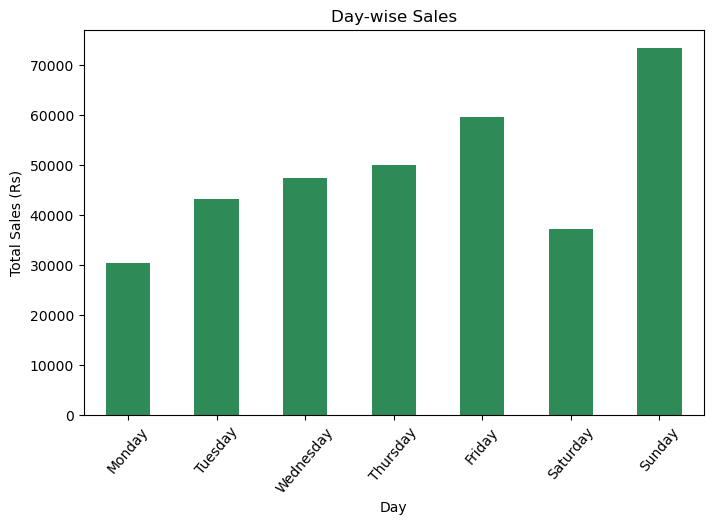

In [85]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sales_by_day.plot(kind='bar',color='seagreen')
plt.title('Day-wise Sales')
plt.xlabel('Day')
plt.ylabel('Total Sales (Rs)')
plt.xticks(rotation=50)
plt.show()

In [86]:
def get_time_slot(hour):
    if 6<=hour<10:
        return 'Morning'
    elif 10<=hour<14:
        return 'Late Morning'
    elif 14<=hour<17:
        return 'Afternoon'
    elif 17<=hour<20:
        return 'Evening'
    return 'Night'
df['Time_Slot']=df['Hour'].apply(get_time_slot)

In [87]:
sales_by_time=df.groupby('Time_Slot')['Bill_Amount'].sum()
print(sales_by_time)
peak_time = sales_by_time.idxmax()
print('Peak shopping duration: ',peak_time)

Time_Slot
Afternoon       155450.0
Evening          72450.0
Late Morning     65475.0
Morning          21770.0
Night            26130.0
Name: Bill_Amount, dtype: float64
Peak shopping duration:  Afternoon


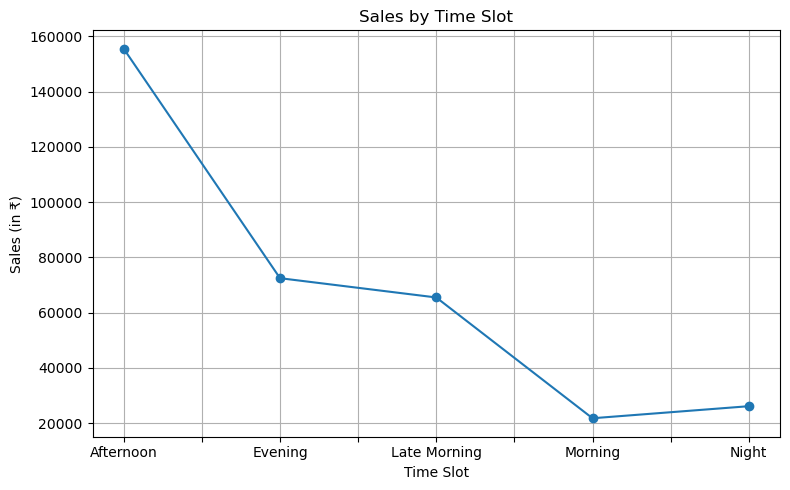

In [88]:
plt.figure(figsize=(8,5)) 
sales_by_time.plot(kind="line", marker="o") 
plt.title("Sales by Time Slot") 
plt.xlabel("Time Slot") 
plt.ylabel("Sales (in ₹)") 
plt.tight_layout()
plt.grid() 
plt.show()

In [89]:
quantity_by_cat = df.groupby("Category")["Quantity"].sum() 
best_cat = quantity_by_cat.idxmax() 
print("Best Selling Category :", best_cat)

Best Selling Category : Grocery


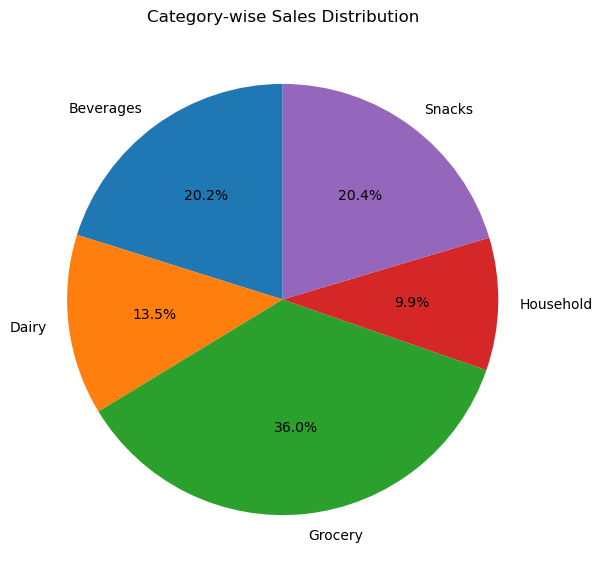

In [90]:
plt.figure(figsize=(7,7)) 
plt.pie(quantity_by_cat, 
        labels=quantity_by_cat.index, 
        autopct="%1.1f%%", 
        startangle=90 
)
plt.title("Category-wise Sales Distribution") 
plt.show()

In [91]:
qty_by_product = df.groupby("Product")["Quantity"].sum() 
best_product = qty_by_product.idxmax() 
print("Best Selling Product: ",best_product)

Best Selling Product:  Rice


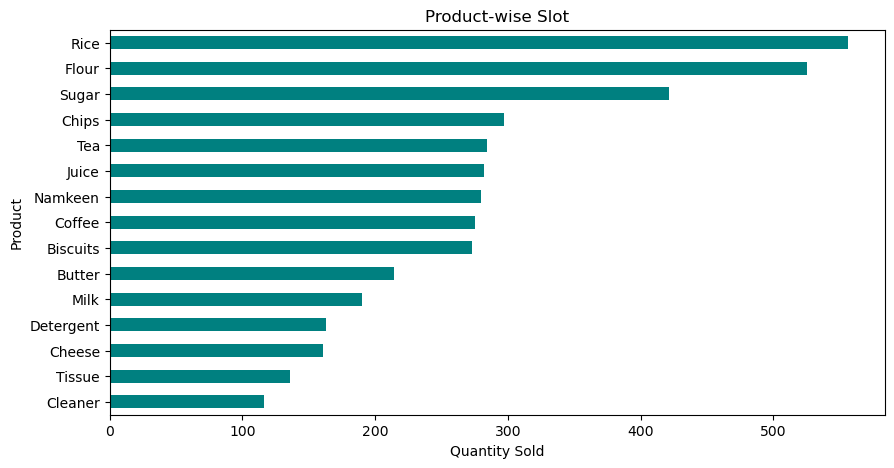

In [92]:
plt.figure(figsize=(10,5))
qty_by_product.sort_values().plot(
    kind='barh',
    color='teal'
)
plt.title('Product-wise Slot')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')
plt.show()

<Axes: xlabel='Category'>

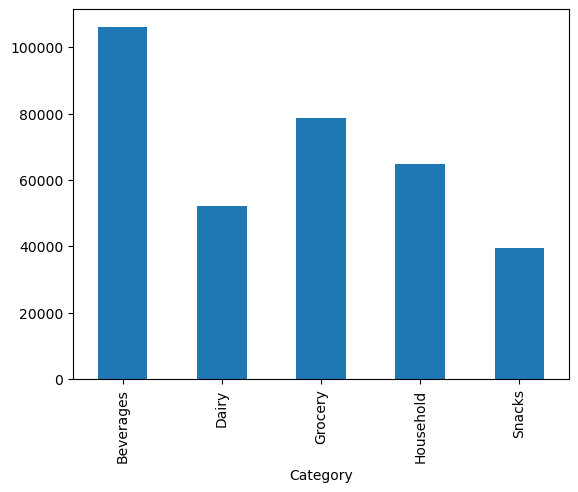

In [93]:
revenue_by_category=df.groupby(
    'Category'
)['Bill_Amount'].sum()
revenue_by_category.plot(kind='bar')

<Axes: xlabel='Product'>

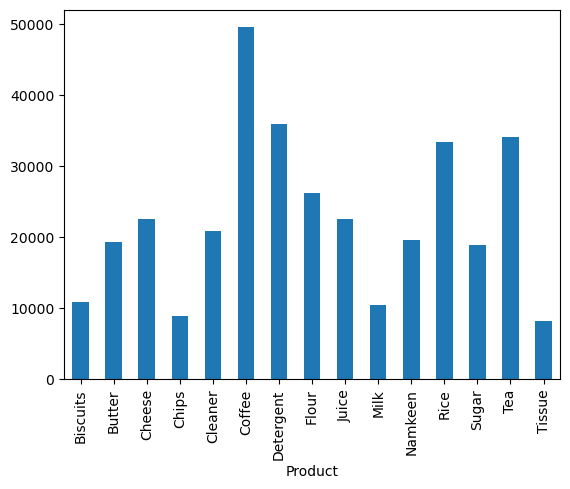

In [94]:
revenue_by_product=df.groupby(
    'Product'
)['Bill_Amount'].sum()
revenue_by_product.plot(kind='bar')

In [95]:
avg_bill_amount=df['Bill_Amount'].mean()
print('Average Bill Amount')
print(f"Rs {avg_bill_amount:.2f}")

Average Bill Amount
Rs 247.30


In [96]:
total_weekly_revenue=df['Bill_Amount'].sum()
print('Total Weekly Revenue')
print(f"Rs {total_weekly_revenue:.2f}")

Total Weekly Revenue
Rs 341275.00


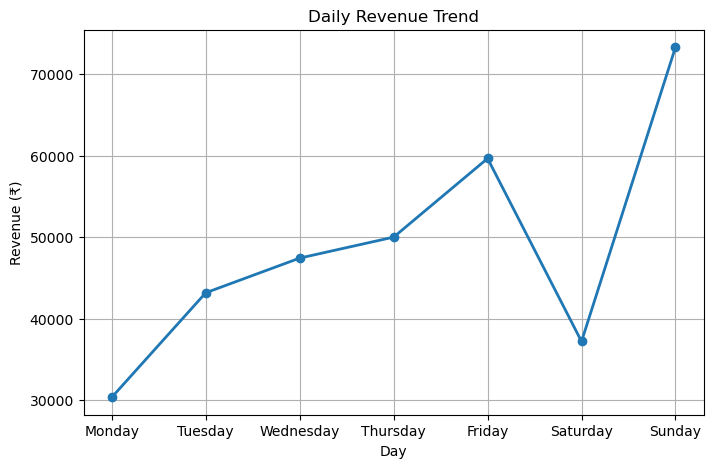

In [97]:
daily_revenue=df.groupby('Day', observed=True)['Bill_Amount'].sum()
plt.figure(figsize=(8,5))
daily_revenue.plot(
    kind='line',
    marker='o',
    linewidth=2
)
plt.title("Daily Revenue Trend")
plt.xlabel("Day") 
plt.ylabel("Revenue (₹)") 
plt.grid() 
plt.show()

In [98]:
avg_customer_rating=df['Rating'].mean()
print('Average customer rating: ', round(avg_customer_rating, 2))

Average customer rating:  4.23


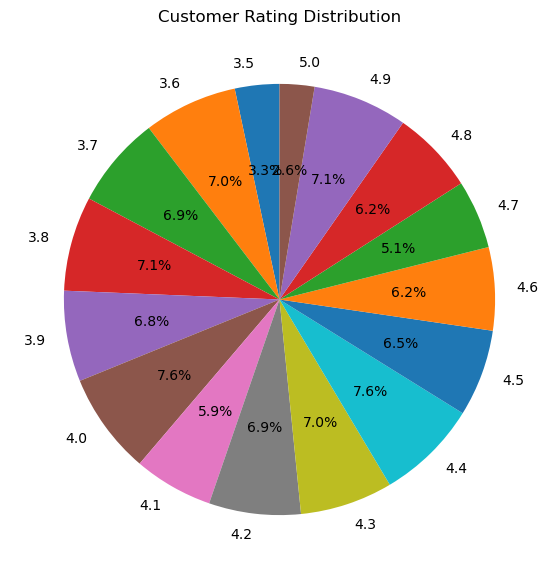

In [99]:
rating_distribution=df['Rating'].value_counts().sort_index()
plt.figure(figsize=(7,7))
plt.pie(
    rating_distribution,
    labels=rating_distribution.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Customer Rating Distribution')
plt.show()

In [100]:
pivot=pd.pivot_table(
    df,
    values='Bill_Amount',
    index='Category',
    columns='Payment_Mode',
    aggfunc='sum'
)
print(pivot)

Payment_Mode     Card     Cash      UPI
Category                               
Beverages     25780.0  20540.0  59820.0
Dairy         15440.0  11420.0  25390.0
Grocery       19410.0  15525.0  43620.0
Household     22980.0   8440.0  33480.0
Snacks         7370.0   8080.0  23980.0


In [101]:
print('RETAIL STORE SALES DASHBOARD')
print(f"Total Transactions   : {len(df)}")
print(f"Total Revenue        : Rs{df['Bill_Amount'].sum():,.2f}")
print(f"Average Bill         : Rs{df['Bill_Amount'].mean():,.2f}")
print(f"Highest Bill         : Rs{df['Bill_Amount'].max():,.2f}")
print(f"Lowest Bill          : Rs{df['Bill_Amount'].min():,.2f}")
print(f"Average Rating       : {df['Rating'].mean():,.2f}")
print(f"Total Discount Given : Rs{df['Discount'].sum():,.2f}")


RETAIL STORE SALES DASHBOARD
Total Transactions   : 1380
Total Revenue        : Rs341,275.00
Average Bill         : Rs247.30
Highest Bill         : Rs1,100.00
Lowest Bill          : Rs30.00
Average Rating       : 4.23
Total Discount Given : Rs10,990.00


In [102]:
bins=[0,300,700,1500,5000]
labels=['Low Spender','Medium Spender','High Spender','Premium Customer']
df['Customer_Segment']=pd.cut(
    df['Bill_Amount'],
    bins=bins,
    labels=labels
)
print(df['Customer_Segment'].value_counts())

Customer_Segment
Low Spender         1061
Medium Spender       243
High Spender          76
Premium Customer       0
Name: count, dtype: int64


<Axes: xlabel='Customer_Segment'>

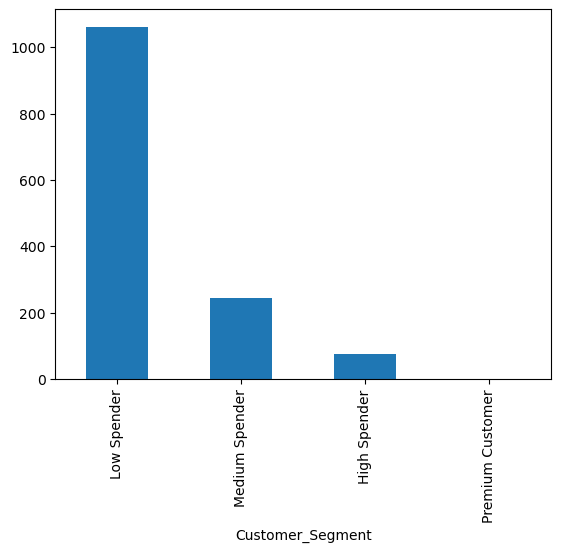

In [103]:
df['Customer_Segment'].value_counts().plot(kind='bar')

In [104]:
while True:
    print("\nBUSINESS SUGGESTIONS MENU")
    print('1. Staff Management')
    print('2. Sales Improvement')
    print('3. Inventory Management')
    print('4. Product Promotion')
    print('5. Payment Recommendations')
    print('6. Customer Satisfaction')
    print('7. View All Suggestions')
    print('8. Exit Suggestions Menu')

    choice=int(input("Enter your choice: "))

    if choice==1:
        print("\nStaff Management")
        print(" - Increase staff on sunday as it records the highest sales.")
        print(" - Open additional billing counters during peak shopping hours.")
    elif choice==2:
        print("\nSales Improvement")
        print(" - Introduce monday discounts to improve customer footfall")
        print(" - Launch saturday combo offers to increase weekend sales.")
    elif choice==3:    
        print("\nInventory Management")
        print(" - Maintain extra inventory from 2PM to 5PM.")
        print(f" - Increase stock of '{best_product}' as it is the best-selling product.")
    elif choice==4:
        print("\Product Promotion")
        print(f" - Promote the '{best_cat}' category using seasonal offers.")
        print(" - Bundle slow-selling products with popular products.")
    elif choice==5:
        print("\nPayment Recommendations")
        print(" - Encourage UPI and Card payments")
        print(" - Offer cashback and reward points on digital payments.")
    elif choice==6:
        print("\nCustomer Satisfaction")
        print(" - Monitor customer ratings regularly.")
        print(" - Inprove service quality and reduce billing waiting time.")
    elif choice==7:
        print("\nAll Business Suggestions")
        print("-"*60)
        print("1. Increase staff on sunday.")
        print("2. Indroduce monday discount offers.")
        print("3. Launch saturday combo offers.")
        print("4. Maintain additional inventory during 2PM - 5PM.")
        print(f"5. Increase stock of '{best_product}'.")
        print(f"6. Promote the '{best_product}' category.")
        print("7. Encourage digital payments with cashback.")
        print("8. Open additional billing counters during peak hours.")
        print("9. Monitor customer rating regularly.")
        print("10. Forecast inventory using weekly sales trends")
    elif choice==8:
        print("\nReturning to Main Menu....")
        break
    else:
        print('Invalid Choice! Please try again.')


BUSINESS SUGGESTIONS MENU
1. Staff Management
2. Sales Improvement
3. Inventory Management
4. Product Promotion
5. Payment Recommendations
6. Customer Satisfaction
7. View All Suggestions
8. Exit Suggestions Menu

Returning to Main Menu....


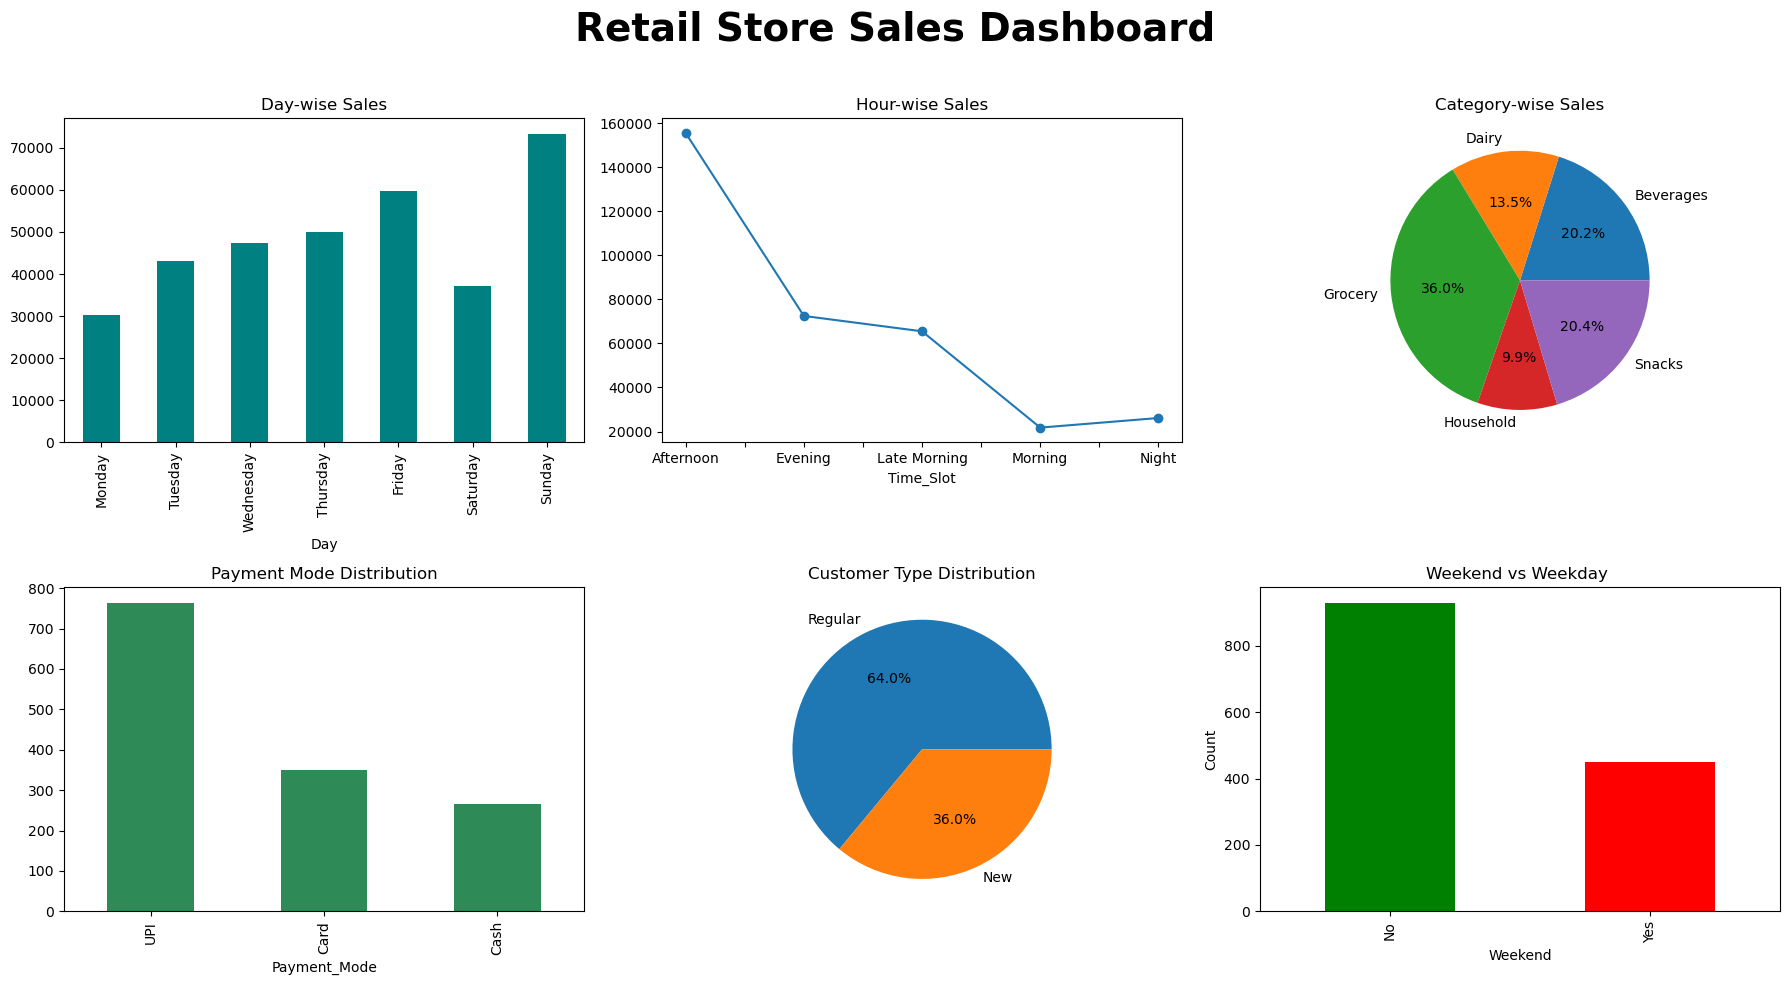

In [105]:
import matplotlib.pyplot as plt 
fig, axes = plt.subplots(2, 3, figsize=(18,10)) 
fig.suptitle(
    "Retail Store Sales Dashboard",
    fontsize=28,    
    fontweight="bold" ) 
# 1. Day-wise Sales
sales_by_day.plot(    
    kind="bar",    
    ax=axes[0,0],    
    color="teal",    
    title="Day-wise Sales" ) 
#  Hour-wise Sales 
sales_by_time.plot(    
    kind="line",    
    ax=axes[0,1],   
    marker="o",    
    title="Hour-wise Sales" ) 
# 3. Category-wise Sales 
quantity_by_cat.plot(    
    kind="pie",    
    ax=axes[0,2],    
    autopct="%1.1f%%" ) 
axes[0,2].set_ylabel("") 
axes[0,2].set_title("Category-wise Sales") 
# 4. Payment Mode Distribution 
payment_mode_count = df["Payment_Mode"].value_counts() 
payment_mode_count.plot(    
    kind="bar",    
    ax=axes[1,0],    
    color="seagreen",    
    title="Payment Mode Distribution" ) 
# 5. Customer Type Distribution 
customer_type = df["Customer_Type"].value_counts() 
customer_type.plot(    
    kind="pie",    
    ax=axes[1,1],
    color=["green", "blue"],
    autopct="%1.1f%%" ) 
axes[1,1].set_ylabel("") 
axes[1,1].set_title("Customer Type Distribution") 
# 6. Weekend vs Weekday Sales 
sales_by_week=df["Is_Weekend"].value_counts() 
sales_by_week.plot(    
    kind="bar",    
    ax=axes[1,2],    
    color=["green", "red"],    
    title="Weekend vs Weekday " )
axes[1,2].set_xlabel("Weekend") 
axes[1,2].set_ylabel("Count") 
plt.tight_layout(rect=[0, 0, 1, 0.96]) 
plt.show()